Logs  
- [2024/08/07]    
  An implementation Hybrid PSO-GWO from (Şenel et al., 2019). First we 
  implement PSO first.

- [2024/08/08]   
  In PSO, we need to decide the three parameters: $w$, $\phi_p$, and $\phi_g$.
  See (Clerc and Kennedy, 2002).

  In (Şenel et al., 2019) the parameters are set according to 
  - (Eberhart and Shi, 2000), and this paper is set according to
    - (Clerc, 1999)

  We clearly see that PSO will fail the $F_1$ case and the solution is trapped  
  in other local minimum for small number of particles.
  Increase the number of particles.


- [2025/06/06]    
  We can fix the program, thanks to my experience teaching artificial    
  intelligence and re-implement PSO from (Rao, 2020) - Engineering Optimization, 
  Section 13.4.   
  The algorithm in that book is not correct, but we fixed by putting   
  domain constraint and some settings in numerical parameters.

- [2025/12/04]      
  Rename this notebook from `pso-prototype.ipynb` to 
  `pso-prototype-numba.ipynb`.   
  Update the code to use `psoalgo_loops_numba.py`


References
- (Clerc, 1999) - The swarm and the queen - towards a deterministic and adaptive
  particle swarm optimization.
- (Clerc and Kennedy, 2002) - The particle swarm - explosion, stability, and
  convergence in a multidimensional complex space
- (Eberhart and Shi, 2000) - Comparing Inertia Weights and Constriction Factors
  in Particle Swarm Optimization
- (Şenel et al., 2019) - A novel hybrid PSO-GWO algorithm for optimization problems
- (Suganthan et al., 2005) - Problem definitions and evaluation criteria for the CEC 2005 special session on real-parameter optimization
- (Zhang et al., 2015) - A Comprehensive Survey on Particle Swarm Optimization
  Algorithm and Its Applications
- CEC 2005 benchmark: https://github.com/yasserglez/cec2005benchmark/tree/master/inst/extdata
- See your past SIMPAS Google Docs proposal: `2024-pso-gwo-algo-arif-proposal`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go   # pip install plotly nbformat (and restart kernel)

from matplotlib.widgets import Slider
from heuristicAlgo import psoalgo_loops_numba
from numba import njit

In [2]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
  'font.size': 16,
  'grid.alpha': 0.25})

In [3]:
%load_ext autoreload
%autoreload 2

## Function test case

$F_1$: Shifted Rotated Weierstrass Function (Suganthan et al., 2005).  

$$
  F_1(x)
    = \sum_{i=1}^D 
      \left(
        \sum_{k=0}^{k_\text{max}}
        \left[
          a^k \cos{(2 \pi b^k (z_i + 0.5))}
        \right]
      \right)
      - D \sum_{k=0}^{k_\text{max}}
        \left[
          a^k \cos{(2 \pi b^k \cdot 0.5)} 
        \right]
      + f_\text{bias}
$$
where $a = 0.5$, $b = 3$, $k_\text{max} = 20$, $z = (x - o) M$,   
$z_i = \sum_{j}(x_{j} - o_j) M_{j, i}$    
$x = [x_1, x_2, \ldots, x_D]$, $o = [o_1, o_2, \ldots, o_D]$, 
$x \in [-0.5, 0.5]$, $f_\text{bias} = 90$

The function in CEC 2005 is numbered $F_{11}$. The filename is
- `weierstrass_data.txt`
- `weierstrass_M_D30.txt`

We minimize $F_{1}$

In [4]:
def obj_func_1(x, o, D, M, a=0.5, b=3, k_max=20):
  f_bias_11 = 90
  z = np.dot((x - o), M)

  k_arr = np.arange(k_max + 1)

  # return a**k_arr 
  term1 = np.sum((a**k_arr)[:, np.newaxis, np.newaxis, np.newaxis]\
    *np.cos((2.*np.pi*b**k_arr)[:, np.newaxis, np.newaxis, np.newaxis] * (z + 0.5)), axis=0)
  term2 = D*np.sum(a**k_arr * np.cos(2.*np.pi*b**k_arr * 0.5), axis=0)
  return np.sum(term1, axis=-1) - term2 + f_bias_11

In [5]:
@njit
def obj_func_1_loops(x, o, D, M, a=0.5, b=3, k_max=20):
  f_bias_11 = 90
  z = np.zeros(D)
  row_M = 2
  for dim in range(D):
    for j in range(row_M):
      z[dim] += (x[j] - o[j]) * M[j, dim]

  k_arr = np.arange(k_max + 1)

  term1 = 0
  for dim in range(D):
    term1sub = 0
    for k in range(k_max):
      term1sub += a**k_arr[k] * np.cos(2.*np.pi*b**k_arr[k]*(z[dim] - 0.5))

    term1 += term1sub
  
  term2 = 0
  for k in range(k_max):
    term2 += a**k_arr[k] * np.cos(2.*np.pi*b**k_arr[k] * 0.5)

  return term1 - D*term2 + f_bias_11

## 3-D map for 2-D function of $F_1$

In [6]:
M_D2 = np.zeros((2, 2)) 
with open("../cec-2005/weierstrass_M_D2.txt") as fp:
  for i, line in enumerate(fp):
    M_D2[i] = np.array(list(map(float, line.strip().split())))

o_arr = None
with open("../cec-2005/weierstrass_data.txt") as fp:
  for i, line in enumerate(fp):
    o_arr = np.array(list(map(float, line.strip().split())))

display(M_D2)
display(o_arr)

array([[ 0.44632867,  1.58946328],
       [-3.93103413, -2.79667085]])

array([-0.1367,  0.1186, -0.0968,  0.0237, -0.2933, -0.0478,  0.3518,
        0.3579, -0.0586, -0.0375,  0.253 ,  0.3165,  0.3974,  0.3813,
        0.1718, -0.2854,  0.0849, -0.18  , -0.0942, -0.1684, -0.1939,
       -0.0154,  0.198 , -0.1252,  0.2211, -0.0536, -0.2085,  0.3883,
       -0.2305,  0.1972,  0.1802, -0.2742,  0.3224,  0.2133,  0.116 ,
       -0.3053,  0.337 ,  0.2232, -0.0619,  0.0743, -0.1337, -0.2071,
        0.2378, -0.1349, -0.0009, -0.2858,  0.1892,  0.0775, -0.3299,
       -0.3864,  0.029 ,  0.1797, -0.3591,  0.2299,  0.2227, -0.0747,
        0.2258, -0.0291, -0.055 ,  0.344 ,  0.0219, -0.3578,  0.3695,
       -0.0036,  0.1446,  0.0133, -0.3803,  0.0483, -0.0406,  0.1314,
       -0.3729, -0.1127, -0.1502, -0.1911, -0.3004, -0.1845, -0.1738,
        0.0771, -0.3186,  0.2763, -0.1197, -0.3663,  0.1649,  0.205 ,
        0.0431,  0.0131, -0.1709,  0.3491, -0.1357,  0.1072,  0.3958,
       -0.2918,  0.1065, -0.3617,  0.0621, -0.0183,  0.0449,  0.3748,
       -0.3578, -0.1

In [7]:
Nx = 100
Ny = 100
D = 2
x_range = [-0.5, 0.5]
y_range = [-0.5, 0.5]

x_space = np.linspace(*x_range, Nx)
y_space = np.linspace(*x_range, Ny)

x_mesh, y_mesh = np.meshgrid(x_space, y_space)
x_tensor = np.stack([x_mesh, y_mesh], axis=-1)

o_tensor = o_arr[np.newaxis, np.newaxis, :D]
# M_tensor = M_D2[np.newaxis, np.newaxis, :]

# display(o_tensor)
# display(M_tensor)
# display(np.shape(x_tensor))
# display(x_tensor)

F_1_vals = obj_func_1(x_tensor, o_tensor, D, M_D2)
np.shape(F_1_vals)

(100, 100)

In [8]:
F_1_min = obj_func_1(o_tensor, o_tensor, D, M_D2)
F_1_min

array([[90.]])

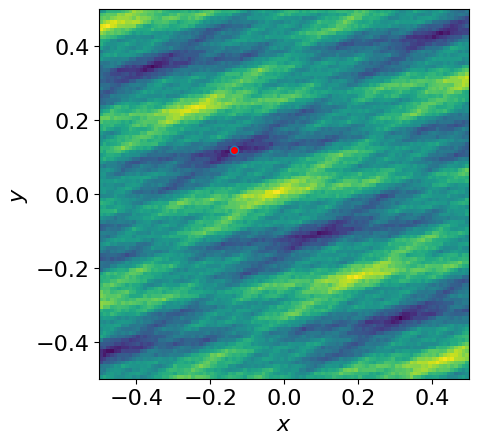

In [9]:
%matplotlib inline
fig, ax = plt.subplots()

ax.imshow(F_1_vals, extent=[*x_range, *y_range], origin="lower")
ax.plot([o_arr[0]], [o_arr[1]], linestyle="None", marker="o",
        markerfacecolor="r")

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

plt.show(fig)

Surface plot version

In [10]:
%matplotlib inline
fig = go.Figure(data=[go.Surface(z=F_1_vals, x=x_space, y=y_space, 
                                  colorscale="Viridis")])

fig.update_traces(contours_z=dict(show=True, usecolormap=True,
                                  highlightcolor="limegreen", project_z=True))

r = 1.5
camera = {"eye": {"x": r, "y": r, "z": r}}
fig.update_layout(autosize=False, width=500, height=400, 
                  scene={"xaxis_title": "x",
                         "yaxis_title": "y",
                         "zaxis_title": "F11"},
                  margin={"l":5, "r":10, "b":5, "t":10},
                  scene_camera=camera,
                  legend={"x": 0.1, "y": 0.9})

fig.show()

## Prototyping initialization

In [30]:
def initialize_particles(bounds, N_particles, rng=None):
  if rng is None:
    print("please provide rng argument with np.random.default_rng()")
  return np.array([rng.uniform(*bound, N_particles) for bound in bounds]).T

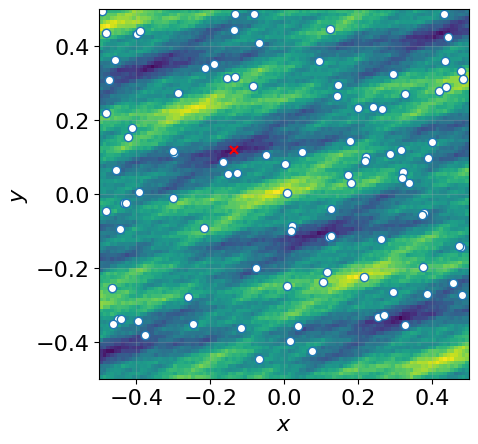

In [31]:
D = 2
bounds = np.reshape([-0.5, 0.5]*D, (-1, D))
N_particles = 100

rng = np.random.default_rng(24_08_07)
# rng = np.random.default_rng()
coor_particles = initialize_particles(bounds, N_particles, rng=rng)
coor_particles

fig, ax = plt.subplots()

ax.imshow(F_1_vals, extent=[*x_range, *y_range], origin="lower")
ax.plot(coor_particles[:, 0], coor_particles[:, 1], linestyle="None", marker="o",
        markerfacecolor="w")
ax.plot(*o_arr[:D], linestyle="None", marker="x", markeredgewidth=1.5,
        markeredgecolor="r")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_aspect("equal")
ax.grid("on")

plt.show(fig)

## Prototyping PSO

From (Zhang et al., 2015)

In [32]:
def run_pso(obj_func, x_init_arr, o_arr, D, M_tensor, bounds, rng=None, iter_max=100):
  x_arr = x_init_arr.copy()

  # numerical parameters are selected by user
  # See (Şenel et al., 2019) page 1367
  # w = 0.7298   # in practice less than 1
  # phi_p = 1.49445  # in range [1, 3]
  # phi_g = 1.49445  # in range [1, 3]

  # My own setting after understanding the algorithm
  w = 0.5
  phi_p = 0.3
  phi_g = 0.3

  data_history = {
    "x_arr": [],
    "v_arr": [],
    "p_arr": [],
    "g_best": []
  }
  # print(x_arr)

  N_particles = len(x_arr)
  # -- Step 1
  # Initialize the particle's best know position to its initial position
  p_arr = x_arr.copy()
  f_p_arr = obj_func_1(p_arr, o_arr, D, M_tensor) 
  g_best = p_arr[np.argmin(f_p_arr)].copy()

  # Initialize the particle's velocity
  v_arr = np.array([rng.uniform(-(bound_high - bound_low), (bound_high - bound_low), 
                        N_particles) 
          for bound_low, bound_high in bounds]).T

  data_history["x_arr"].append(x_arr.copy())
  data_history["v_arr"].append(v_arr.copy())
  data_history["p_arr"].append(p_arr.copy())
  data_history["g_best"].append(g_best.copy())


  # -- Step 2: Repeat until a termination criteria is met
  run_algo = True   # termination flag
  iter_start = 0
  while run_algo:
    for i in range(N_particles):
      r_p = rng.uniform(size=D)
      r_g = rng.uniform(size=D)

      # -- update the particle's velocity
      v_arr[i] = w*v_arr[i] + phi_p*r_p*(p_arr[i] - x_arr[i]) + phi_g*r_g*(g_best - x_arr[i])

      # -- update the particle's position
      x_arr[i] += v_arr[i]

      # -- if the particle's position is outside the domain, we set it to the 
      # boundary point. This is the constraint of our optimization
      # this constraint will set the solution to be a point on the boundary
      for bound in bounds:
        if x_arr[i, 0] < bound[0]:
          x_arr[i, 0] = bound[0]
        if x_arr[i, 1] > bound[1]:
          x_arr[i, 1] = bound[1]


      f_x_i = obj_func(x_arr[i][np.newaxis, :], o_arr, D, M_tensor)[0]
      f_p_i = obj_func(p_arr[i][np.newaxis, :], o_arr, D, M_tensor)[0]
      f_g = obj_func(g_best[np.newaxis, :], o_arr, D, M_tensor)[0]
      if f_x_i < f_p_i:
        # Update the particle's best known position
        p_arr[i] = x_arr[i].copy()

        if f_p_i < f_g:
          # Update the swarm's best known position
          g_best = p_arr[i].copy()
    
    data_history["x_arr"].append(x_arr.copy())
    data_history["v_arr"].append(v_arr.copy())
    data_history["p_arr"].append(p_arr.copy())
    data_history["g_best"].append(g_best.copy())
    
    iter_start += 1
    if iter_start > iter_max:
      run_algo = False

  return g_best, data_history

- `bounds` $(N \times 2)$        
  $\begin{bmatrix}x_{1,\text{min}} & x_{1,\text{max}} 
    \\ x_{2,\text{min}} & x_{2, \text{max}}
    \\ \vdots & \vdots 
    \\ x_{N,\text{min}} & x_{N, \text{max}} \end{bmatrix}$

- `coor_particles = x_arr` $(N \times D)$    
  $\begin{bmatrix} x_{1,1} & x_{1, 2} & \ldots & x_{1, D}
    \\ x_{2,1} & x_{2,2} & \ldots & x_{2,D} 
    \\ \vdots & \vdots & & \vdots 
    \\ x_{N,1} & x_{N,2} & \ldots & x_{N,D} \end{bmatrix}$

- `o_sol = o_arr[:D][np.newaxis, :]` $(1 \times D)$    
  $\begin{bmatrix} o_{1} & o_{2} & \ldots & o_{D}
  \end{bmatrix}$

- `M_tensor = M_D2[np.newaxis, :, :]` $(1, 2, 2)$   

In [33]:
o_arr[:D][np.newaxis, :]

array([[-0.1367,  0.1186]])

In [34]:
M_D2[np.newaxis, :, :]

array([[[ 0.44632867,  1.58946328],
        [-3.93103413, -2.79667085]]])

Computational time
- `N=400`, `iter_max=100`: 8 secs

In [35]:
D = 2
bounds = np.reshape([-0.5, 0.5]*D, (-1, 2))     # 2 in here is low and high values

# N_particles = 400
# N_particles = 100
N_particles = 50

o_sol = o_arr[:D][np.newaxis, :]
M_tensor = M_D2[np.newaxis, :, :]

rng = np.random.default_rng(24_08_07)
# rng = np.random.default_rng()
coor_particles = initialize_particles(bounds, N_particles, rng=rng)

iter_max = 100

g_best, data_history = run_pso(obj_func_1, coor_particles, o_sol, D, M_tensor, 
                                bounds, rng=rng, iter_max=iter_max)

In [36]:
data_history["x_arr"][0].shape

(50, 2)

In [37]:
g_best

array([-0.46914496, -0.42791641])

In [38]:
len(data_history["g_best"])

102

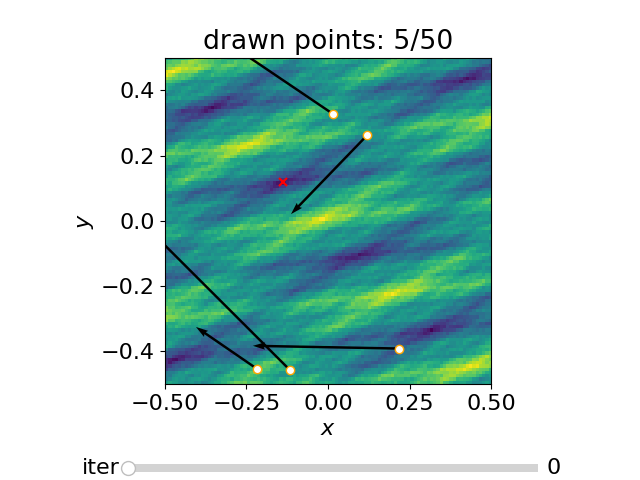

In [39]:
%matplotlib widget

fig, ax = plt.subplots()

ax.imshow(F_1_vals, extent=[*x_range, *y_range], origin="lower")
ax.plot([o_arr[0]], [o_arr[1]], linestyle="None", marker="x",
        markeredgecolor="r", markeredgewidth=1.5)
ax_pos = ax.get_position()
ax_pos.y0 = 0.2
ax.set_position(ax_pos)

# -- horizontal slider
iter = np.arange(iter_max)
ax_t = fig.add_axes([0.2, 0.01, 0.64, 0.03])
t_slider = Slider(ax=ax_t, label="iter", valmin=0, valmax=iter_max, valstep=1,
                  valinit=0)

skip_points = 10
for i in range(1):
  history_x_arr = data_history["x_arr"][i].copy()
  history_v_arr = data_history["v_arr"][i].copy()
  history_g_best = data_history["g_best"][i].copy()
  plot_handler = ax.plot(history_x_arr[::skip_points, 0], 
                          history_x_arr[::skip_points, 1], linestyle="None", 
                          marker="o", markerfacecolor="w", markeredgecolor="orange")

  quiver_handler = ax.quiver(history_x_arr[::skip_points, 0], history_x_arr[::skip_points, 1], 
            history_v_arr[::skip_points, 0], history_v_arr[::skip_points, 1],
            units="xy", scale_units="xy", scale=1.)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(f"drawn points: {len(coor_particles[::skip_points])}/{N_particles}")

# print(dir(quiver_handler))


# -- slider update function 
def update_slider(val):
  val = int(val)
  history_x_arr = data_history["x_arr"][val].copy()
  history_v_arr = data_history["v_arr"][val+1].copy()
  plot_handler[0].set_xdata(history_x_arr[::skip_points, 0])
  plot_handler[0].set_ydata(history_x_arr[::skip_points, 1])
  quiver_handler.set_offsets(history_x_arr[::skip_points])
  quiver_handler.set_UVC(history_v_arr[::skip_points, 0], history_v_arr[::skip_points, 1])
  fig.canvas.draw_idle()

t_slider.on_changed(update_slider)

plt.show(fig)

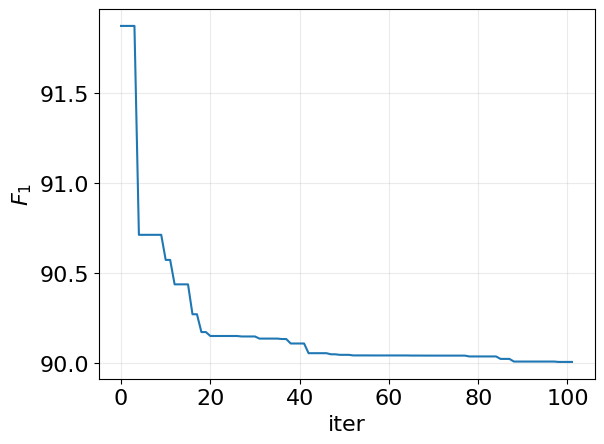

In [41]:
%matplotlib inline

fig, ax = plt.subplots()

history_g_best = data_history["g_best"]
ax.plot(obj_func_1(history_g_best, o_sol, D, M_tensor))

ax.set_ylabel("$F_1$")
ax.set_xlabel("iter")
ax.grid("on")

plt.show(fig)

Test for $N$ runs

In [57]:
D = 2
bounds = np.reshape([-0.5, 0.5]*D, (-1, 2))     # 2 in here is low and high values

# N_particles = 400
N_particles = 50

o_sol = o_arr[:D]
# M_tensor = M_D2[np.newaxis, :, :]
M_tensor = M_D2.copy()

seed = 25_12_05
rng = np.random.default_rng(seed)
# rng = np.random.default_rng()
# coor_particles = initialize_particles(bounds, N_particles, rng=rng)

iter_max = 100

runs_history = {
  "best_solution": [], 
  "best_fitness": [], 
  "history_p_arr": [], 
  "history_f_p_arr": []
}

# num_of_runs = 10      # 1 min 25 secs / 400 particles

# num_of_runs = 100     # 1 min 43 secs / 50 particles
num_of_runs = 1000      # 17 mins 6 secs / 50 particles

w = 0.5
phi_p = 0.3
phi_g = 0.3
params = [w, phi_p, phi_g]

for i in range(num_of_runs):
  print(f"run: {i}")
  history_p_arr, history_f_p_arr, history_g_best, history_f_g_best \
    = psoalgo_loops_numba.run_pso_loops_numba(
        obj_func_1_loops, N_particles, o_sol, D, M_tensor, bounds, 
        params, rng, iter_max=iter_max)
  # best_solution = data_history["g_best"]
  # best_fitness = obj_func_1(best_solution, o_sol, D, M_tensor)
  runs_history["best_solution"].append(history_g_best)
  runs_history["best_fitness"].append(history_f_g_best)
  runs_history["history_p_arr"].append(history_p_arr)
  runs_history["history_f_p_arr"].append(history_f_p_arr)

run: 0
run: 1
run: 2
run: 3
run: 4
run: 5
run: 6
run: 7
run: 8
run: 9
run: 10
run: 11
run: 12
run: 13
run: 14
run: 15
run: 16
run: 17
run: 18
run: 19
run: 20
run: 21
run: 22
run: 23
run: 24
run: 25
run: 26
run: 27
run: 28
run: 29
run: 30
run: 31
run: 32
run: 33
run: 34
run: 35
run: 36
run: 37
run: 38
run: 39
run: 40
run: 41
run: 42
run: 43
run: 44
run: 45
run: 46
run: 47
run: 48
run: 49
run: 50
run: 51
run: 52
run: 53
run: 54
run: 55
run: 56
run: 57
run: 58
run: 59
run: 60
run: 61
run: 62
run: 63
run: 64
run: 65
run: 66
run: 67
run: 68
run: 69
run: 70
run: 71
run: 72
run: 73
run: 74
run: 75
run: 76
run: 77
run: 78
run: 79
run: 80
run: 81
run: 82
run: 83
run: 84
run: 85
run: 86
run: 87
run: 88
run: 89
run: 90
run: 91
run: 92
run: 93
run: 94
run: 95
run: 96
run: 97
run: 98
run: 99
run: 100
run: 101
run: 102
run: 103
run: 104
run: 105
run: 106
run: 107
run: 108
run: 109
run: 110
run: 111
run: 112
run: 113
run: 114
run: 115
run: 116
run: 117
run: 118
run: 119
run: 120
run: 121
run: 122
run

In [70]:
is_saved = True
filename = f"./results/PSO-with-loop-numba-numOfRuns-{num_of_runs}-Nparticles-{N_particles}-iterMax-{iter_max}.npz"

if is_saved:
  np.savez(filename, best_solution=runs_history["best_solution"], 
            best_fitness=runs_history["best_fitness"], 
            history_p_arr=runs_history["history_p_arr"], 
            history_f_p_arr=runs_history["history_f_p_arr"])

Reload data

In [13]:
N_particles = 50
iter_max = 100
num_of_runs = 1000

filename = f"./results/PSO-with-loop-numba-numOfRuns-{num_of_runs}-Nparticles-{N_particles}-iterMax-{iter_max}.npz"
runs_history = np.load(filename, allow_pickle=True)

History plots for many runs

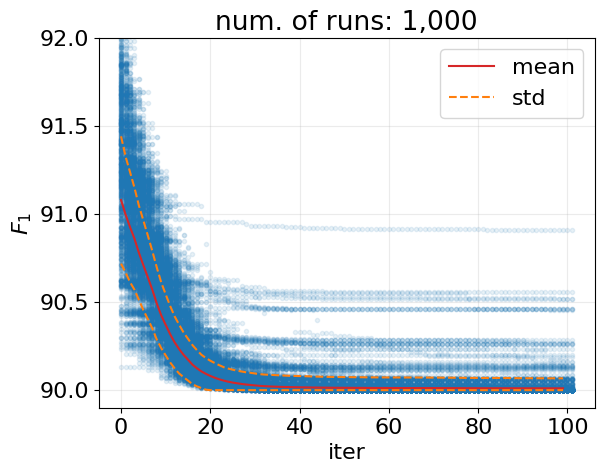

In [14]:
fig, ax = plt.subplots()

temp_sum = np.zeros(iter_max)
for history_f_g_best in runs_history["best_fitness"]:
  ax.plot(history_f_g_best, color="tab:blue", alpha=0.1, 
          linestyle="None", marker=".")
  # print(f"g_best_F1", g_best_F1.shape)
  temp_sum += np.array(history_f_g_best).flatten()[2:]

runs_mean = temp_sum/num_of_runs

runs_std = np.zeros(iter_max)
temp_var = np.zeros(iter_max)
for history_f_g_best in runs_history["best_fitness"]:
  temp_var += (np.array(history_f_g_best).flatten()[2:] - runs_mean)**2

runs_std = np.sqrt(temp_var/num_of_runs)
ax.plot(runs_mean, color="tab:red", label="mean")
ax.plot(runs_mean + runs_std, color="tab:orange", label="std", linestyle="--")

lower_bound = runs_mean - runs_std
lower_bound[lower_bound < 90] = 90
ax.plot(lower_bound, color="tab:orange", label=None, linestyle="--")

ax.set_ylabel("$F_1$")
ax.set_xlabel("iter")
ax.set_ylim([89.9, 92])

ax.set_title(f"num. of runs: {num_of_runs:,}")
ax.grid("on")
ax.legend(loc="best")


plt.show(fig)

In [15]:
np.shape(runs_history["best_fitness"])

(1000, 102)

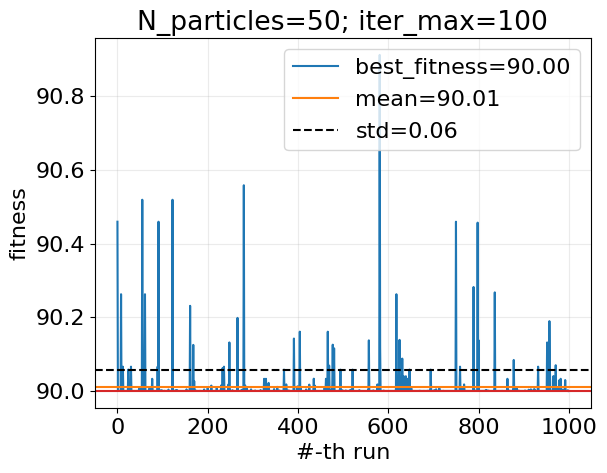

In [ ]:
fig, ax = plt.subplots()

runs_best_fitness = np.array([best_fitness[-1] for best_fitness in runs_history["best_fitness"]])
ax.plot(runs_best_fitness, label=f"best_fitness={np.min(runs_best_fitness):.2f}")

# -- average and its stddev
mean_runs_best_fitness = np.mean(runs_best_fitness)
ax.axhline(mean_runs_best_fitness, color="tab:orange", 
            label=f"mean={mean_runs_best_fitness:.2f}")
stddev_runs_best_fitness = np.std(runs_best_fitness)
ax.axhline(F_1_min + stddev_runs_best_fitness, color="k",
            linestyle="--", label=f"std={stddev_runs_best_fitness:.2f}")

# -- ground truth
ax.axhline(F_1_min, color="tab:red")

ax.grid("on")
ax.set_xlabel("#-th run")
ax.set_ylabel("fitness")
ax.set_title(f"N_particles={N_particles}; iter_max={iter_max}")
ax.legend(loc="best")

plt.show(fig)